# Implementation of a Variational Autoencoder, Step by Step (PyTorch)

# Learning Objectives

By the end of this notebook, you should be able to:

- explain the difference between a plain (deterministic) autoencoder and a variational autoencoder
- explain why a VAE encodes a **distribution** (mean and log-variance) instead of a single point in latent space
- implement the **reparameterization trick** and explain why it is necessary for backpropagation
- derive and implement the two components of the VAE loss (reconstruction + KL divergence)
- visualize and interpret a 2D latent space
- generate new, plausible digit images by sampling from the latent space
- discuss the role of the `beta` weighting factor in the VAE loss (beta-VAE)

# Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

np.random.seed(42)
torch.manual_seed(42)

PyTorch version: 2.11.0+cu128
Using device: cuda


# Load and Prepare the MNIST Dataset

In [ ]:
train_dataset_raw = datasets.MNIST(root="./data", train=True, download=True)
test_dataset_raw = datasets.MNIST(root="./data", train=False, download=True)

x_train = (train_dataset_raw.data.numpy() / 255.0).astype("float32")
y_train = train_dataset_raw.targets.numpy()
x_test = (test_dataset_raw.data.numpy() / 255.0).astype("float32")
y_test = test_dataset_raw.targets.numpy()

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.60MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]


x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)


# Hyperparameters

**Improvement / simplification over the original notebook:** in the Keras version, `batch_size` had to be **hardcoded into the model's `Input` layer** (`Input(batch_shape=(batch_size, 28, 28, 1))`), because the `noiser` function sampled Gaussian noise of a fixed shape `(batch_size, hidden_dim)`. This meant the trained model could only ever be used with that exact batch size at inference time (a real limitation e.g. for generating a single image).

In PyTorch, we sample noise with `torch.randn_like(mean)`, whose shape automatically matches whatever batch size is passed in — so the model works with **any** batch size, including 1, without any special handling.

In [ ]:
hidden_dim = 2   # size of the latent space (kept at 2 so we can visualize it directly, as in the original notebook)
batch_size = 128 # only used for training; the model itself is not tied to this value (see note above)

# Encoder

The encoder maps a `28 x 28` image to the parameters of a Gaussian distribution in latent space: a **mean** vector and a **log-variance** vector, both of size `hidden_dim`.

**Comment on `Dropout` + `BatchNorm`:** as in the original notebook, we apply `BatchNorm` followed by `Dropout` after each hidden dense layer, as a light regularization measure. This is not strictly necessary for a VAE (the KL term already acts as a regularizer), but it can help stabilize training on more complex datasets.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, hidden_dim=2, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout),
        )
        self.fc_mean = nn.Linear(128, hidden_dim)
        self.fc_log_var = nn.Linear(128, hidden_dim)

    def forward(self, x):
        h = self.net(x)
        mean = self.fc_mean(h)
        log_var = self.fc_log_var(h)
        return mean, log_var


encoder = Encoder(hidden_dim=hidden_dim).to(device)
print(encoder)

Encoder(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): ReLU()
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Dropout(p=0.3, inplace=False)
  )
  (fc_mean): Linear(in_features=128, out_features=2, bias=True)
  (fc_log_var): Linear(in_features=128, out_features=2, bias=True)
)


# Latent Space — the Reparameterization Trick

Instead of directly outputting a latent vector, the encoder outputs a **mean** and a **log-variance**. We then *sample* a latent vector `z` from `N(mean, exp(log_var))`.

The problem: sampling is a **random, non-differentiable** operation, so gradients cannot flow back through it during backpropagation.

**The reparameterization trick** solves this by rewriting the sampling step as:

$$z = \text{mean} + e^{\text{log\_var}/2} \cdot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, 1)$$

Now the randomness comes only from `epsilon`, which does not depend on the network's parameters — so gradients can flow through `mean` and `log_var` normally, while `epsilon` is just treated as a constant input at each forward pass.

**Improvement over the original notebook:** the original `noiser` function used **Python global variables** (`global mean, log_var`) to smuggle `mean`/`log_var` out of a Keras `Lambda` layer for use later in the loss function — a fragile pattern. In PyTorch, the encoder simply **returns** `mean` and `log_var` directly (see above), and the reparameterization step below only needs them as function arguments — no globals required.

In [ ]:
def reparameterize(mean, log_var):
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)   # eps has the same shape and dtype/device as std automatically
    return mean + std * eps

# Decoder

The decoder takes a latent vector `z` of size `hidden_dim` and reconstructs a `28 x 28` image. The final `Sigmoid` activation ensures pixel outputs are in `[0, 1]`.

In [ ]:
class Decoder(nn.Module):
    def __init__(self, hidden_dim=2, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, z):
        x = self.net(z)
        return x.view(-1, 28, 28)


decoder = Decoder(hidden_dim=hidden_dim).to(device)
print(decoder)

Decoder(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=784, bias=True)
    (9): Sigmoid()
  )
)


# Full VAE Model

We assemble the encoder, the reparameterization step, and the decoder into a single `nn.Module`. The `forward` method returns everything the loss function needs: the reconstruction, and the `mean` / `log_var` used to compute the KL divergence.

In [ ]:
class VAE(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        mean, log_var = self.encoder(x)
        z = reparameterize(mean, log_var)
        reconstruction = self.decoder(z)
        return reconstruction, mean, log_var


vae = VAE(encoder, decoder).to(device)
total_params = sum(p.numel() for p in vae.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 470,804


# Loss — the Evidence Lower Bound (ELBO)

The VAE is trained by maximizing the **Evidence Lower Bound (ELBO)**, or equivalently minimizing:

$$\mathcal{L} = \underbrace{\text{reconstruction loss}}_{\text{how well } x \text{ is reconstructed}} + \underbrace{D_{KL}(q(z|x) \, \| \, p(z))}_{\text{how close the latent distribution is to a standard normal}}$$

**Improvement over the original notebook:** the original reconstruction term was a raw **sum of squared errors** (`tf.reduce_sum(tf.square(x - y))`), which implicitly assumes a Gaussian decoder with a fixed, somewhat arbitrary variance. Since our decoder ends with a `Sigmoid` and pixel values are in `[0, 1]`, we instead use **binary cross-entropy** here, which corresponds to a *Bernoulli* likelihood — the more standard and better-motivated choice for MNIST-style pixel intensities, and the same choice we used for the plain autoencoders in the earlier lab.

**Improvement over the original notebook:** we also expose a `beta` weight on the KL term (as in **beta-VAE**). Setting `beta > 1` encourages a more disentangled, but less sharply reconstructed, latent space; `beta < 1` favors reconstruction quality over a clean latent structure. The original notebook used a fixed, implicit `beta = 1`; we keep `beta = 1` by default but make it explicit and easy to change.

In [ ]:
def vae_loss(recon_x, x, mean, log_var, beta=1.0):
    batch_size = x.size(0)

    recon_x_flat = recon_x.view(batch_size, -1)
    x_flat = x.view(batch_size, -1)

    # Reconstruction term: Bernoulli log-likelihood (binary cross-entropy), summed over pixels, averaged over the batch
    recon_loss = F.binary_cross_entropy(recon_x_flat, x_flat, reduction="sum") / batch_size

    # KL divergence between q(z|x) = N(mean, exp(log_var)) and the standard normal prior N(0, 1)
    kl_loss = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp(), dim=1)
    kl_loss = kl_loss.mean()

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

# Training Setup

In [ ]:
optimizer = optim.Adam(vae.parameters())
beta = 1.0

train_dataset = TensorDataset(torch.tensor(x_train))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

**Improvement over the original notebook:** rather than relying on Keras's default `.fit()` output (a single combined loss number per epoch), we track the **reconstruction loss** and **KL loss** separately at every epoch. This is very useful in practice: if the KL loss collapses to (near) zero early in training, it's a classic sign of **posterior collapse** (the decoder ignores the latent code entirely), while a KL loss that dominates the total loss suggests reconstructions may suffer.

In [ ]:
def train_vae(model, train_loader, optimizer, device, epochs=25, beta=1.0):
    history = {"loss": [], "recon_loss": [], "kl_loss": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_recon = 0.0
        running_kl = 0.0
        total = 0

        for (xb,) in train_loader:
            xb = xb.to(device)

            optimizer.zero_grad()
            recon_x, mean, log_var = model(xb)
            loss, recon_loss, kl_loss = vae_loss(recon_x, xb, mean, log_var, beta=beta)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            running_recon += recon_loss.item() * xb.size(0)
            running_kl += kl_loss.item() * xb.size(0)
            total += xb.size(0)

        history["loss"].append(running_loss / total)
        history["recon_loss"].append(running_recon / total)
        history["kl_loss"].append(running_kl / total)

        print(f"Epoch {epoch+1}/{epochs} - loss: {history['loss'][-1]:.2f} "
              f"- recon: {history['recon_loss'][-1]:.2f} - kl: {history['kl_loss'][-1]:.4f}")

    return history


epochs = 25
history = train_vae(vae, train_loader, optimizer, device, epochs=epochs, beta=beta)

Epoch 1/25 - loss: 248.95 - recon: 244.71 - kl: 4.2369
Epoch 2/25 - loss: 170.59 - recon: 165.87 - kl: 4.7173
Epoch 3/25 - loss: 166.88 - recon: 161.87 - kl: 5.0005
Epoch 4/25 - loss: 164.86 - recon: 159.66 - kl: 5.1911
Epoch 5/25 - loss: 163.41 - recon: 158.07 - kl: 5.3416
Epoch 6/25 - loss: 162.52 - recon: 157.09 - kl: 5.4232
Epoch 7/25 - loss: 161.78 - recon: 156.31 - kl: 5.4689
Epoch 8/25 - loss: 161.22 - recon: 155.66 - kl: 5.5621
Epoch 9/25 - loss: 160.44 - recon: 154.83 - kl: 5.6137
Epoch 10/25 - loss: 160.04 - recon: 154.41 - kl: 5.6318
Epoch 11/25 - loss: 159.77 - recon: 154.11 - kl: 5.6552
Epoch 12/25 - loss: 159.38 - recon: 153.69 - kl: 5.6831
Epoch 13/25 - loss: 159.08 - recon: 153.41 - kl: 5.6773
Epoch 14/25 - loss: 158.74 - recon: 153.03 - kl: 5.7087
Epoch 15/25 - loss: 158.59 - recon: 152.88 - kl: 5.7109
Epoch 16/25 - loss: 158.24 - recon: 152.51 - kl: 5.7228
Epoch 17/25 - loss: 157.99 - recon: 152.24 - kl: 5.7505
Epoch 18/25 - loss: 157.98 - recon: 152.23 - kl: 5.7489
E

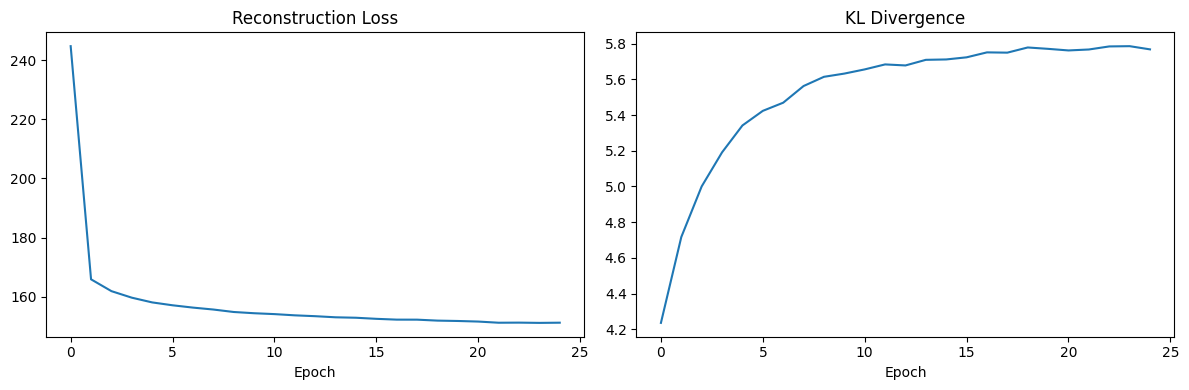

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["recon_loss"])
plt.title("Reconstruction Loss")
plt.xlabel("Epoch")

plt.subplot(1, 2, 2)
plt.plot(history["kl_loss"])
plt.title("KL Divergence")
plt.xlabel("Epoch")

plt.tight_layout()
plt.show()

**Question:** does the KL loss stay near zero throughout training (a sign of posterior collapse), grow steadily, or stabilize at some intermediate value? What would you expect to see in each case?

# Latent Space

We encode a batch of test images and plot their `(mean_1, mean_2)` coordinates in the 2D latent space.

**Improvement over the original notebook:** the original scatter plot showed all points in a single color, with no way to tell which digit each point corresponds to. We color the points by their true digit label (available in `y_test`, even though the VAE itself never sees these labels during training) — this makes it possible to see whether the unsupervised latent space has spontaneously organized itself by digit identity.

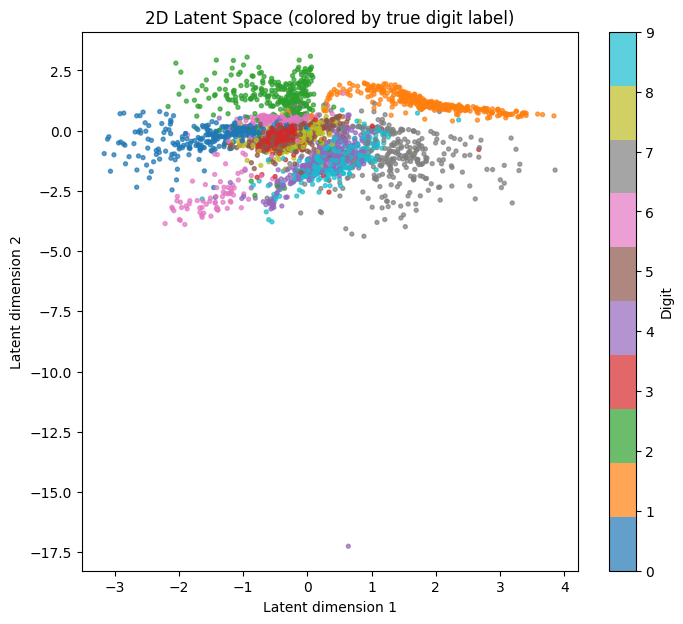

In [ ]:
vae.eval()
with torch.no_grad():
    x_sample = torch.tensor(x_test[:3000]).to(device)
    mean_sample, _ = vae.encoder(x_sample)
    h = mean_sample.cpu().numpy()

plt.figure(figsize=(8, 7))
scatter = plt.scatter(h[:, 0], h[:, 1], c=y_test[:3000], cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, label="Digit")
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("2D Latent Space (colored by true digit label)")
plt.show()

# Results — Decoding a Single Point

We can pick an arbitrary point in latent space and decode it into an image, to see what the model generates there.

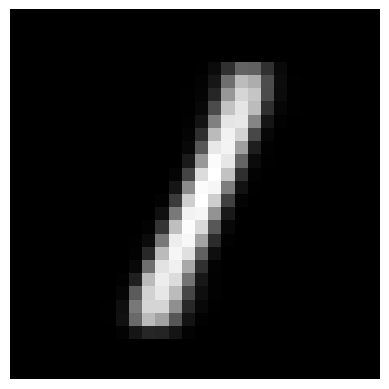

In [ ]:
vae.eval()
with torch.no_grad():
    z = torch.tensor([[0.94, 2.0]], dtype=torch.float32).to(device)
    image = vae.decoder(z).cpu().numpy()

plt.imshow(image.squeeze(), cmap="gray")
plt.axis("off")
plt.show()

# Results — Exploring the Latent Space Grid

We now decode a regular grid of points across the 2D latent space, to visualize how the generated digits change as we move continuously through the latent space. A smooth, meaningful transition between digit shapes (rather than abrupt jumps or unrelated blobs) is a good sign that the VAE has learned a well-structured latent space.

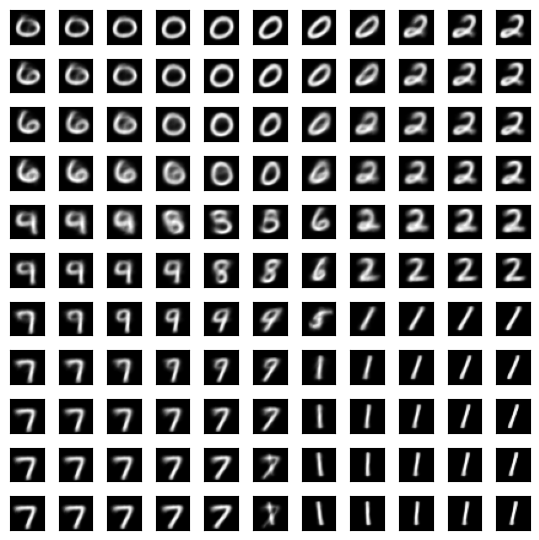

In [ ]:
n = 5
size = 2 * n + 1

plt.figure(figsize=(size / 2, size / 2))
num = 1

vae.eval()
with torch.no_grad():
    for i in range(-n, n + 1):
        for j in range(-n, n + 1):
            ax = plt.subplot(size, size, num)
            num += 1
            z = torch.tensor([[3 * i / n, 3 * j / n]], dtype=torch.float32).to(device)
            image = vae.decoder(z).cpu().numpy()
            plt.imshow(image.squeeze(), cmap="gray")
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

# Final Questions

1. What is the fundamental difference between a plain (deterministic) autoencoder and a variational autoencoder, both in terms of architecture and in terms of what each is used for?
2. Why does the encoder output a `mean` **and** a `log_var`, instead of directly outputting a single latent vector `z`?
3. Explain in your own words why the reparameterization trick is necessary. What would go wrong if we sampled `z` directly from `N(mean, exp(log_var))` without it?
4. What does the KL divergence term in the loss actually encourage the model to do? What would likely happen to the latent space if this term were removed entirely (i.e. training with reconstruction loss only)?
5. What is "posterior collapse", and how could you detect it from the training curves plotted above?
6. What is the effect of increasing `beta` (e.g. `beta = 5`) on the trade-off between reconstruction quality and latent space structure? Try it and describe what you observe.
7. Why was `hidden_dim` set to `2` in this notebook? What would you gain and lose by increasing it to, say, `10` or `20`?
8. Looking at the latent space scatter plot colored by digit: do visually similar digits (e.g. `4` and `9`, or `3` and `8`) end up close to each other in latent space? Why might that happen even though the model never saw the labels during training?
9. In the latent space grid, do you observe smooth transitions between digit shapes as you move across the grid? What does a "smooth" versus "discontinuous" latent space tell you about what the model has learned?
10. What practical differences did you notice between the Keras and PyTorch versions of this notebook (e.g. handling of `mean`/`log_var` without global variables, batch-size independence, explicit reparameterization function, separate tracking of reconstruction vs. KL loss)?

# Answer

# Answer

1. Plain Autoencoder vs. Variational Autoencoder

* **Architecture**:
  * A **Plain Autoencoder (AE)** is entirely deterministic. The encoder maps an input $x$ to a single fixed point vector $z$ in the latent space. The decoder maps that point back to reconstruct $x$.
  * A **Variational Autoencoder (VAE)** is probabilistic. Instead of mapping to a single point, the encoder outputs the parameters of a probability distribution (the mean $\mu$ and log-variance $\log\sigma^2$). A point $z$ is then sampled from this distribution to be passed to the decoder.
* **Use Cases**:
  * **AE** is primarily used for **dimensionality reduction**, compression, or denoising. Its latent space is often unconstrained and has "gaps" or empty zones, making it poor at generating new data.
  * **VAE** is a **generative model**. The probabilistic constraint (enforced by the KL divergence) structures the latent space into a continuous distribution (usually standard normal), allowing us to easily sample random vectors and generate new, novel, yet realistic data.



2. Outputting Mean and Log-Variance
Instead of outputting a single vector $z$, the encoder outputs $\mu$ (mean) and $\log\sigma^2$ (log-variance) so that we can represent a **probability distribution** $q(z|x) = \mathcal{N}(\mu, \Sigma)$ over the latent space.

This distribution formulation captures the **uncertainty** of our representation and ensures that the encoder maps an input to an entire *neighborhood* in the latent space rather than a single isolated coordinate. This neighborhood-based representation directly supports the continuous structure required for smooth interpolation and generation.



3. The Reparameterization Trick

* **Why it is necessary**: In a standard formulation, we sample $z \sim \mathcal{N}(\mu, \sigma^2)$. Sampling is a stochastic, non-deterministic operation. If we sample directly, we cannot write a deterministic derivative of $z$ with respect to $\mu$ and $\sigma^2$, which means **gradients cannot flow backward** through the sampling node to update the encoder.
* **What goes wrong without it**: Backpropagation breaks completely. The optimizer would not be able to train the encoder because it would receive no gradients indicating how changing $\mu$ and $\sigma^2$ impacts the reconstruction loss.
* **How it works**: We express $z = \mu + \sigma \odot \epsilon$, where $\epsilon \sim \mathcal{N}(0, I)$ is an external random noise variable. Because the randomness is isolated within $\epsilon$, the computation path from $\mu$ and $\sigma$ to $z$ becomes fully differentiable, allowing normal backpropagation.



4. Role of the KL Divergence Term

* **What it encourages**: The KL Divergence term acts as a regularizer. It penalizes the latent distribution $q(z|x)$ for deviating from the prior distribution $p(z) = \mathcal{N}(0, I)$. It forces the mean vectors close to $0$ and the variances close to $1$.
* **Without the KL Term (Reconstruction Loss only)**: The model behaves exactly like a deterministic autoencoder. The encoder will place different classes (digits) into far-apart clusters with zero overlap, maximizing distances to make reconstruction easier. This creates huge, empty "dead zones" in the latent space. Sampling a random point from these dead zones would yield completely chaotic, unrealistic noise instead of recognizable digits.



5. Posterior Collapse

* **What it is**: Posterior collapse occurs when the VAE's decoder becomes strong enough (or the regularization too dominant) that it completely ignores the latent variables $z$. As a result, the encoder maps all inputs to the prior distribution $\mathcal{N}(0, I)$, meaning $\mu \approx 0$ and $\log\sigma^2 \approx 0$.
* **How to detect it from curves**: In the training curves, you will see the **KL Divergence drop and stay very close to zero** (or completely collapse to zero), while the **reconstruction loss remains high** or fails to improve significantly.



6. Effect of Increasing Beta ($\beta$-VAE)

* **The Trade-off**: Increasing $\beta$ (e.g., $\beta = 5$) places more weight on the KL divergence term relative to the reconstruction loss.
* **Observation**:
  * **Latent Space**: Undergoes a stronger force toward a standard normal distribution. The latent coordinates shrink closer to $(0,0)$, and different digit classes overlap more, encouraging a more "disentangled" or organized, symmetrical representation.
  * **Reconstruction**: The generated images become significantly blurrier. Because the model is forced to prioritize the KL penalty, it sacrifices pixel-level fidelity (reconstruction details).



7. Why `hidden_dim` was set to 2

* **Why 2**: Keeping `hidden_dim = 2` allows us to **directly visualize** the entire latent space on a standard 2D scatter plot and decode a 2D grid to observe transitions without using dimensionality reduction techniques like t-SNE or PCA.
* **Increasing to 10 or 20**:
  * **Gain**: Better reconstructions! The model has much more capacity to encode complex features, style variances, and structural variations, resulting in significantly sharper and more accurate digit generations.
  * **Loss**: We lose the ability to easily map and visualize the latent space directly on a 2D plane, and we can no longer simply map a regular coordinate grid to show transitions.


8. Similar Digits in the Scatter Plot

* **Do they end up close?** Yes, visually similar digits (such as 4 and 9, or 3 and 8) tend to cluster closely or overlap in the latent space.
* **Why?** Since the VAE is trained on **unsupervised reconstruction loss** (binary cross-entropy), the encoder and decoder must share similar pathways for images that share structural features. If a 9 is simply a 4 with a closed loop on top, their representations must be close in latent space so the decoder can reconstruct both using similar generative features.


9. Smooth vs. Discontinuous Transitions

* **Do we see smooth transitions?** Yes, in a well-trained VAE, moving from one quadrant to another shows a gradual transformation (e.g., a '1' slowly tilts and gains a loop to become a '2' or an '8').
* **What it tells us**: A **smooth** latent space indicates that the model has successfully learned the true, continuous underlying manifold of the dataset. A **discontinuous** space (with abrupt jumps or meaningless noise) would indicate that the latent representation has failed to capture the continuous semantic features and has merely memorized specific points.


10. Practical Differences: Keras vs. PyTorch

* **No Global Variables**: In PyTorch, we return `mean` and `log_var` directly from the encoder's `forward` function, clean and object-oriented. The Keras version utilized global scope to extract variables from within custom Lambda layers.
* **Batch-Size Independence**: PyTorch generates noise dynamically with `torch.randn_like(mean)`, meaning the model adapts on-the-fly to a batch size of 1 during evaluation or generation, whereas the Keras version had static input dimensions fixed to `batch_size` during both training and inference.
* **Explicit Functions**: Writing the custom loop in PyTorch makes the exact calculations of the reconstruction and KL losses fully transparent, giving us granular tracking of both metrics rather than relying on Keras's opaque `.fit()` abstraction.